# 00 Fetch and Parse Data

In this markdown we download the "training" (labelled) and inference data from HuggingFace. Then, we conduct some data cleaning and parsing.

In [1]:
import huggingface_hub
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

## Download data

In [2]:
REPO_ID = "CosmicDustGroup/cassini-cda-spectra"
FILENAME_INF = "data/lvl2/cda_qm_spectra_pre2008277_inf_lvl2.parquet"
FILENAME_TRAIN = "data/lvl2/cda_qm_spectra_pre2008277_train_lvl2.parquet"

# Download the inference file
file_inf_path = huggingface_hub.hf_hub_download(
    repo_id=REPO_ID, 
    filename=FILENAME_INF, 
    repo_type="dataset"
)

print(f"File downloaded to: {file_inf_path}")

# Download the training file
file_train_path = huggingface_hub.hf_hub_download(
    repo_id=REPO_ID, 
    filename=FILENAME_TRAIN, 
    repo_type="dataset"
)

print(f"File downloaded to: {file_train_path}")

File downloaded to: /root/.cache/huggingface/hub/datasets--CosmicDustGroup--cassini-cda-spectra/snapshots/2527e3274e4fd3c4be019d8c6ff8848990acbfba/data/lvl2/cda_qm_spectra_pre2008277_inf_lvl2.parquet
File downloaded to: /root/.cache/huggingface/hub/datasets--CosmicDustGroup--cassini-cda-spectra/snapshots/2527e3274e4fd3c4be019d8c6ff8848990acbfba/data/lvl2/cda_qm_spectra_pre2008277_train_lvl2.parquet


## A look in the data

The inferece data loading time is a little bit longer, due to its size of around 600 MB. Both datasets have 5 "common" columns:

- sclk: The spacecraft clock of the Cassini spacecraft. This is like a unique identifier for an impact event. The smallest number (basically... 1) corresponding to 1 second and is the smallest time-resolution of the instrument (dead time of 1 s bascially)
- f_desc / event_id: Some identifier for the geo-scientists. Not of interest for us. Their spectrum viewer app requires these things for later
- specrum: Spectra with the data. Just to be 100 % sure: we will filter for 1018 datapoints. These are so-called "shrinking 1" spectra. 509 corresponding to shrinking 2; like a "spectrum-zip". But these data are rarely considered
- qi_ampl: Now that's interesting: we had a small ion-grid in front of the analyzer. The height / amplitude of the signal corresponds, in fact, to the quality of the signal. A higher Signal-to-Noise ration corresponds to a higher amplitude. These values are given in Coloumb. Some of my colleagues say that a threshold of at least 10 fC shall be reached; else the spectra shall be discarded. (1 fC = 1e-15). I slightly disagree. In my upcoming AI paper I was able to improve some signal processing down to 1 fC... So a filtering could be done in a later stage!

The training data has of course the class label :)!

In [3]:
train_df = pd.read_parquet(file_train_path)
inf_df = pd.read_parquet(file_inf_path)

In [4]:
train_df

,sclk,f_desc,event_id,spectrum,qi_ampl,class
0,1.477582e+09,6405615,4035,"[-6.986339e-07, 0.0, 0.0, -8.7329244e-07, 5.23...",5.004700e-14,Noise
1,1.477619e+09,6405615,6860,"[-1.7465848e-07, -8.7329244e-07, -1.7465848e-0...",4.182420e-14,3-Car
2,1.477626e+09,6405615,10363,"[-1.7465848e-07, -1.7465848e-07, -1.7465848e-0...",1.700580e-14,3-Car
3,1.477630e+09,6405615,12290,"[-3.4931696e-07, -3.4931696e-07, -3.4931696e-0...",1.312510e-14,3-KNa
4,1.477666e+09,6405615,16489,"[-6.986339e-07, 0.0, -3.4931696e-07, -5.239755...",4.949150e-12,Noise
...,...,...,...,...,...,...
19815,1.595941e+09,6405611,5152,"[-8.7329244e-07, -3.4931696e-07, -5.239755e-07...",1.660380e-12,4
19816,1.600362e+09,6405611,27,"[-3.4931696e-07, 0.0, 0.0, -6.986339e-07, 3.49...",8.706700e-14,4
19817,1.600365e+09,6405611,264,"[-6.986339e-07, -1.7465848e-07, -1.047951e-06,...",1.470450e-14,4
19818,1.600365e+09,6405611,271,"[0.0, -5.239755e-07, -1.7465848e-07, -3.493169...",4.963500e-13,4


In [5]:
# Class distribution in the training set
class_counts = train_df['class'].value_counts()
print("Class distribution in the training set:")
print(class_counts)

Class distribution in the training set:
class
Noise    12077
1         4491
2         1015
3          909
?          553
4          263
5          186
3-Car       89
3-Cl        47
3-OH        47
3-KNa       41
5-Na        41
3-P         34
3-K         22
2-X          3
X            2
Name: count, dtype: int64


## 1018 filtering

First, let's filter out any potential shrinking 2 data out

In [6]:
# Consider only training and inference data with spectra length of 1018 & compre the results before and after filtering
train_df_1018 = train_df[train_df['spectrum'].apply(len) == 1018]
inf_df_1018 = inf_df[inf_df['spectrum'].apply(len) == 1018]

print(f"Training set size before filtering: {len(train_df)}, after filtering: {len(train_df_1018)}")
print(f"Inference set size before filtering: {len(inf_df)}, after filtering: {len(inf_df_1018)}")

Training set size before filtering: 19820, after filtering: 19820
Inference set size before filtering: 755136, after filtering: 755136


## Cropping the spectra

Based on internal discussion, the spectra shall be "cropped" in the "region of interest": Index 10 to 640. That way we can reduce the size of the spectra and may use some more example in the Gemini context

*WE HAVE TO BE AWARE OF RE-PROMPTING THE GEMINI INSTRUCTIONS*

In [7]:
def crop_spectrum(spectrum):
    return spectrum[10:641]
train_df_1018['spectrum'] = train_df_1018['spectrum'].apply(crop_spectrum)
inf_df_1018['spectrum'] = inf_df_1018['spectrum'].apply(crop_spectrum)

## Re-Assign some labels...

Some classes are sketchy. 2-X and X are basically "?" and under-represented. I would suggest to move the "class 3" spectra to the inferece data set, since these data need to be re-classified. Also: These 909 spectra would then be a great, additional, test case to assign them to one of the sub-classes (3-Car, etc.)

In [8]:
train_df_1018['class'] = train_df_1018['class'].apply(lambda x: '?' if "X" in x else x)

Additionally, let's "move" the class 3 spectra to the inference data. However, let's create a third "class 3" dataframe for later!

In [9]:
# Remove "class 3" form the training set, create a new dataframe for class 3 and put the data in the inference set
class_3_df_1018 = train_df_1018[train_df_1018['class'] == '3']
train_df_1018 = train_df_1018[train_df_1018['class'] != '3']
inf_df_1018 = pd.concat([inf_df_1018, class_3_df_1018], ignore_index=True)   

In [10]:
# Class distribution in the training set
class_counts = train_df_1018['class'].value_counts()
print("Class distribution in the training set:")
print(class_counts)

Class distribution in the training set:
class
Noise    12077
1         4491
2         1015
?          558
4          263
5          186
3-Car       89
3-Cl        47
3-OH        47
3-KNa       41
5-Na        41
3-P         34
3-K         22
Name: count, dtype: int64


## Scaling the spectra

Finally, we can scale the spectra in log10 (or similar). That way, the high-dynamic range shall be more obvious

In [11]:
def qm_scaling(spectrum):

    # Apply a log10 on the spectrum + minimum. If min = 0, convert the resulting NaN values
    # accordingly
    spectrum = np.log10(spectrum + np.abs(np.min(spectrum)))
    spectrum = np.nan_to_num(spectrum, neginf=0)

    # Scale the spectrum to be between 0 and 1
    spectrum = (spectrum - np.min(spectrum)) / (np.max(spectrum) - np.min(spectrum))
    return spectrum

train_df_1018['spectrum_scaled'] = train_df_1018['spectrum'].apply(qm_scaling)
inf_df_1018['spectrum_scaled'] = inf_df_1018['spectrum'].apply(qm_scaling)
class_3_df_1018['spectrum_scaled'] = class_3_df_1018['spectrum'].apply(qm_scaling)

/tmp/ipykernel_15231/2320933767.py:5: RuntimeWarning: divide by zero encountered in log10
  spectrum = np.log10(spectrum + np.abs(np.min(spectrum)))
/tmp/ipykernel_15231/2320933767.py:5: RuntimeWarning: divide by zero encountered in log10
  spectrum = np.log10(spectrum + np.abs(np.min(spectrum)))
/tmp/ipykernel_15231/2320933767.py:9: RuntimeWarning: invalid value encountered in divide
  spectrum = (spectrum - np.min(spectrum)) / (np.max(spectrum) - np.min(spectrum))


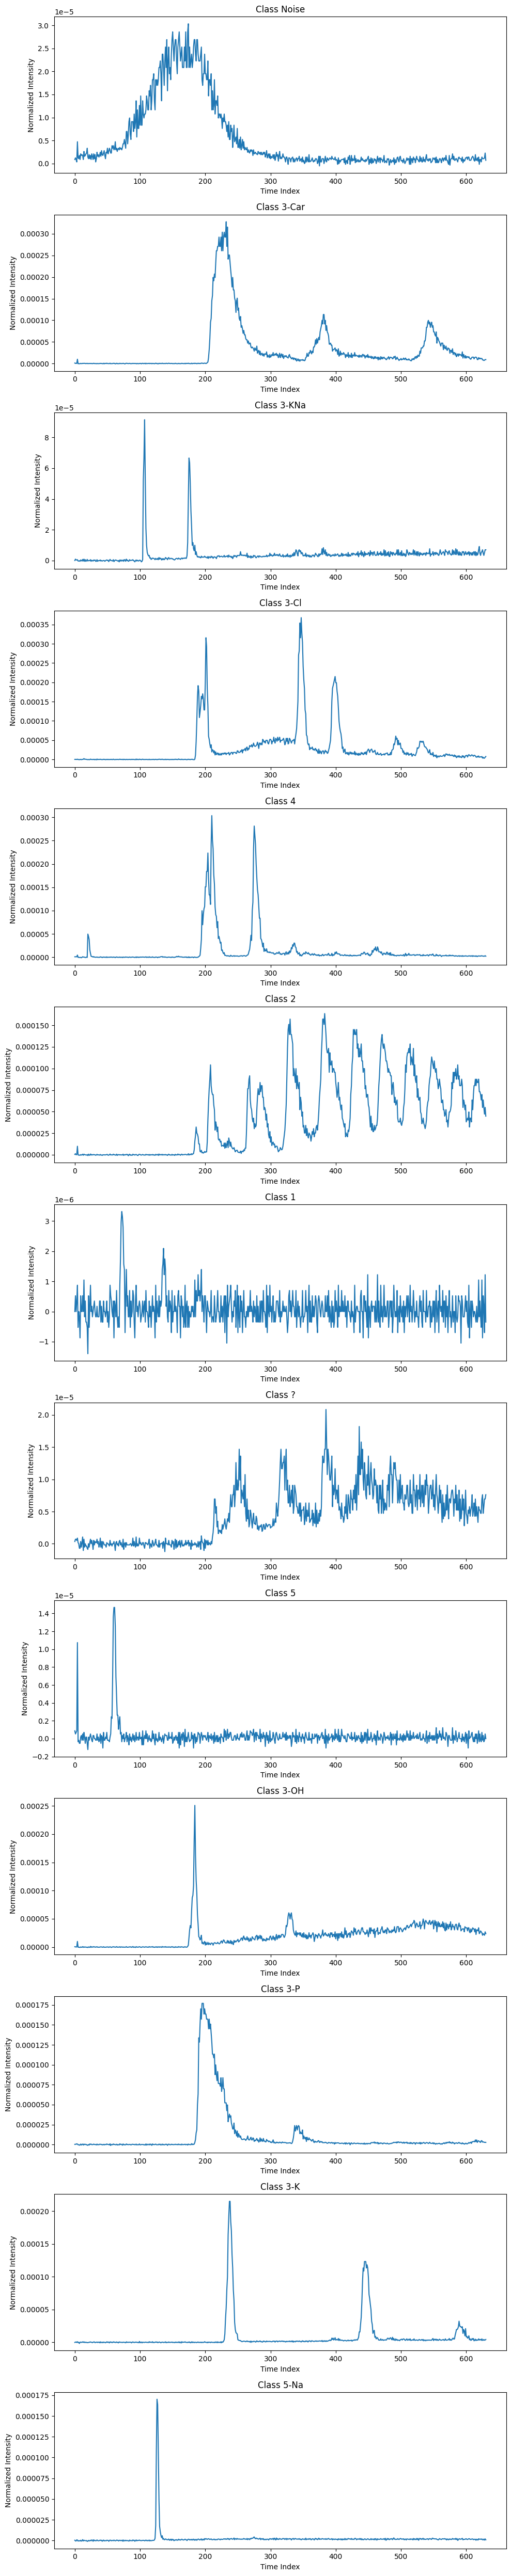

In [14]:
# Plot the first 1 spectrum of each class in the training set in a grid (13 classes)
classes = train_df_1018['class'].unique()
num_classes = len(classes)
fig, axes = plt.subplots(nrows=num_classes, ncols=1, figsize=(10, 50))
for i, cls in enumerate(classes):
    spectrum = train_df_1018[train_df_1018['class'] == cls]['spectrum'].iloc[0]
    axes[i].plot(spectrum)
    axes[i].set_title(f"Class {cls}")
    axes[i].set_xlabel("Time Index")
    axes[i].set_ylabel("Normalized Intensity")
plt.tight_layout()
plt.show()